In [80]:
import numpy as np 
import pandas as pd 

In [81]:
df = pd.read_csv('data/visits.csv')
df.head()

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
0,6a4a715f-94c5-4b5d-8f51-51f07f298fb6,P59581,N1565,2025-09-02 00:08:24,2025-09-02 00:55:24,Wound Care,East,The nurse changed the wound dressing. The pati...
1,27bfc4de-9dd2-4b6b-b05f-f9560a3fd00f,P66547,N5698,"August 24, 2025 10:42PM","August 25, 2025 12:12AM",General Check-up,East,The nurse reviewed the oxygen level. The patie...
2,9c2d0018-8f20-4789-a383-906d49042fbc,P47919,N3012,2025-09-02 11:07:33,2025/09/02 11:56,Physical Therapy,East,Review is required. The nurse assisted the mob...
3,bbedc08d-0ada-4c8f-bac4-3008ac279a01,P18359,N8991,2025-09-15 21:24:42,2025-09-15 22:12:42,General Check-up,North,Follow-up is required. The nurse reviewed the ...
4,155c3765-22d5-41cc-95f5-a94ef19748ae,P45602,N7948,2025-08-31 07:19:11,2025-08-31 07:47:11,Pyhcisal Therapy,North,ASAP is required. The nurse observed the patie...


In [82]:
df.dtypes

visit_id            object
patient_id          object
nurse_id            object
visit_start_time    object
visit_end_time      object
service_type        object
visit_location      object
nurse_notes         object
dtype: object

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   visit_id          1000 non-null   object
 1   patient_id        1000 non-null   object
 2   nurse_id          1000 non-null   object
 3   visit_start_time  1000 non-null   object
 4   visit_end_time    900 non-null    object
 5   service_type      1000 non-null   object
 6   visit_location    1000 non-null   object
 7   nurse_notes       900 non-null    object
dtypes: object(8)
memory usage: 62.6+ KB


In [84]:
df.isna().any()

visit_id            False
patient_id          False
nurse_id            False
visit_start_time    False
visit_end_time       True
service_type        False
visit_location      False
nurse_notes          True
dtype: bool

In [85]:
## format the datetime columns
df['visit_start_time'] = pd.to_datetime(df['visit_start_time'], format='mixed')

In [86]:
df['visit_end_time'] = pd.to_datetime(df['visit_end_time'], format='mixed')

In [87]:
## inspect any missing data in the visit_end_time column
df[df['visit_end_time'].isna()]

## it is possible that the visit_end_time is missing because onging vists but have to check the duration of the visit_start_time to confirm this

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
11,c34e645d-6639-4c79-a281-a70e45368624,P98143,N9438,2025-08-25 14:00:00,NaT,General Check-up,Notrh,Review is required. ##--## The nurse monitored...
16,dce0428d-df95-4399-93cf-97122440fb10,P46024,N5472,2025-08-25 22:05:44,NaT,Physical Therapy,West,The nurse monitored the strength training. The...
22,d7cebb55-ad6d-49a5-a0ff-c513f6a9b456,P18780,N4701,2025-09-05 12:17:00,NaT,Medication Administration,North,The nurse provided the injection. The patient ...
24,e475f174-df8c-4b05-af82-ade9e5fd86e7,P79915,N4605,2025-08-21 01:15:00,NaT,Medication Administration,North,ASAP is required. The nurse provided the oral ...
27,81819e77-549d-4b5b-911a-cac30d9f913e,P65943,N8068,2025-09-03 02:21:45,NaT,Wound Care,East,The nurse changed the bandage. The patient is ...
...,...,...,...,...,...,...,...,...
957,cf26149b-3546-446f-8298-67e335a40629,P59451,N3997,2025-09-02 02:47:43,NaT,Physical Therapy,West,The nurse assisted the mobility exercise. The ...
971,8bb83f0e-4eae-4293-9c95-454d95a17b5d,P86804,N1960,2025-08-29 23:18:00,NaT,General Check-up,West,Review is required. The nurse checked the vita...
977,cc248126-04d2-4900-aea2-c4cb6a684ed3,P84794,N9821,2025-09-02 02:54:02,NaT,Wound Care,East,The nurse changed the incision site. The patie...
983,e523684e-7b18-4657-8358-2c5d10fc6129,P87348,N3681,2025-09-01 14:28:00,NaT,Wound Care,South,The nurse changed the wound dressing. The pati...


In [88]:
## inspect any missing data in the nurse_notes column
df[df['nurse_notes'].isna()]

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
19,a04499ba-cea9-4fd1-91a5-4ef93a25980a,P67227,N7368,2025-08-31 19:55:00,2025-08-31 21:43:49,Wound Cae,North,NaN
85,a7c0d48c-26d5-47f4-a5c6-97b93fb08c0b,P60703,N1066,2025-08-20 20:30:41,2025-08-20 21:42:41,Medicatn Adminstratino,East,NaN
90,b5d08dee-8e18-4f56-bd6b-3801c163e84f,P12283,N9403,2025-09-16 04:27:00,2025-09-16 04:37:25,General Check-up,South,NaN
105,a94d75b9-64f2-4f90-86b3-f3bad0a0c2c3,P23151,N9438,2025-09-03 05:56:34,2025-09-03 06:46:34,Wound Care,East,NaN
111,57965f7b-ec1b-4439-8cac-b6eb7fa8d4ae,P13387,N3978,2025-09-18 00:21:00,2025-09-18 01:07:00,General Check-up,East,NaN
...,...,...,...,...,...,...,...,...
922,263e117a-9fbe-4399-8124-df594770e3a5,P47749,N2248,2025-09-01 09:57:00,2025-09-01 10:12:38,Wound Care,West,NaN
938,364104f6-cd23-44fe-80ef-5ef73b20bd26,P43492,N5633,2025-08-28 21:21:12,NaT,Wound Care,West,NaN
951,c1c93f32-b6fa-41e2-aa19-d00223d82e22,P64395,N8916,2025-09-09 13:53:08,NaT,Medication Administration,East,NaN
969,dc04178c-8238-43f8-8fd2-f95abff9dd91,P27118,N7325,2025-08-29 09:36:01,2025-08-29 11:16:00,Medication Administration,East,NaN


In [89]:
df['visit_id'].nunique()

970

In [90]:
# keep the last visit for each visit_id and drop the rest of the duplicates

df = df.sort_values('visit_start_time')
df = df.drop_duplicates(subset='visit_id', keep='last')
len(df)

970

In [91]:
# change the data type of the visit_id, patient_id and nurse_id columns to string
df['visit_id'] = df['visit_id'].astype('string')
df['patient_id'] = df['patient_id'].astype('string')
df['nurse_id'] = df['nurse_id'].astype('string')

In [92]:
# change the data type of service_type and visit_location
df['service_type'] = df['service_type'].astype('category')
df['visit_location'] = df['visit_location'].astype('category')

In [93]:
# change the data type of the nurse_notes column to string
df['nurse_notes'] = df['nurse_notes'].astype('string')

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 970 entries, 835 to 122
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   visit_id          970 non-null    string        
 1   patient_id        970 non-null    string        
 2   nurse_id          970 non-null    string        
 3   visit_start_time  970 non-null    datetime64[ns]
 4   visit_end_time    873 non-null    datetime64[ns]
 5   service_type      970 non-null    category      
 6   visit_location    970 non-null    category      
 7   nurse_notes       874 non-null    string        
dtypes: category(2), datetime64[ns](2), string(4)
memory usage: 55.7 KB


In [95]:
## check if there are any urgent notes in the nurse_notes column
df[df['nurse_notes'].str.contains(
    'urgent|asap|critical',
    case=False,
    na=False
)]

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
121,e288d71b-4874-486a-826d-3b4e3598560f,P33297,N2536,2025-08-20 00:40:37,2025-08-20 01:01:37,Physical Therapy,Wsst,Critical is required. The nurse assisted the m...
313,4b3d0ec1-9a0b-4ae3-9f5a-3736f7c8dee4,P57919,N3507,2025-08-20 03:50:04,NaT,Wound Care,South,The nurse dressed the incision site. The patie...
785,e44dbd31-5a07-4908-8819-512d7d224666,P55858,N9821,2025-08-20 13:01:00,2025-08-20 13:17:00,Medication Administration,West,ASAP is required. The nurse delivered the oral...
24,e475f174-df8c-4b05-af82-ade9e5fd86e7,P79915,N4605,2025-08-21 01:15:00,NaT,Medication Administration,North,ASAP is required. The nurse provided the oral ...
781,826e8c7f-6f68-4435-99db-5e56093972a4,P30369,N8880,2025-08-21 22:08:06,2025-08-21 23:45:00,Wound Care,East,The nurse applied the incision site. The patie...
...,...,...,...,...,...,...,...,...
395,738ed0db-8dbb-4390-874b-ac8d2b218931,P60050,N5551,2025-09-17 05:10:14,2025-09-17 06:51:00,Wound Care,South,Urgent is required. The nurse changed the band...
941,9265e57e-c916-48a8-a2ad-14235bed3c8d,P83843,N9098,2025-09-17 05:54:00,2025-09-17 07:09:11,Wound Care,East,The nurse applied the wound dressing. The pati...
614,0473b24f-5df9-41a0-b056-e592b1f1959f,P84794,N4957,2025-09-17 08:55:38,2025-09-17 10:05:38,Physical Therapy,East,The nurse encouraged the strength training. Th...
973,c466951c-4ed8-4f41-bcf5-87fa2231de30,P57997,N8916,2025-09-17 11:39:22,2025-09-17 13:11:22,Physical Therapy,East,ASAP is required. The nurse encouraged the mob...


In [96]:
## create a new column called urgent_case that is True if the nurse_notes column contains the words urgent, asap or critical and False otherwise
df['urgent_case'] = df['nurse_notes'].str.contains(
        'urgent|asap|critical',
    case=False,
    na=False
)
df['urgent_case'].value_counts()

urgent_case
False    791
True     179
Name: count, dtype: Int64

In [97]:
## check if there any wording for revisit/follow up in the nurse_notes column
df[df['nurse_notes'].str.contains(
    'revisit|follow up|follow-up|followup',
    case=False,
    na=False
)]

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes,urgent_case
837,b16257ff-36be-4bee-91db-51f38c5533e6,P88018,N2340,2025-08-19 14:22:52,2025-08-19 15:02:00,Medication Administration,South,Follow-up is required. The nurse delivered the...,False
644,68f897eb-e031-43f7-99eb-f3a7db8898e1,P61936,N7969,2025-08-19 18:17:24,2025-08-19 19:16:00,Wound Care,South,Follow-up is required. The nurse applied the w...,False
832,8dd60537-4084-4161-a674-8be320f1a77f,P54147,N5170,2025-08-19 20:07:55,2025-08-19 21:40:55,Wound Care,East,The nurse dressed the wound dressing. The pati...,False
508,7fa24cd5-a00d-4df0-9279-3403b63661d3,P40492,N8286,2025-08-20 13:18:22,2025-08-20 14:29:22,Wound Care,North,The nurse changed the wound dressing. The pati...,False
959,0d587b1c-3023-4c92-976e-adef9cad430d,P95155,N4983,2025-08-20 14:45:31,2025-08-20 15:54:31,Medication Administration,West,The nurse administered the injection. The pati...,False
...,...,...,...,...,...,...,...,...,...
751,844a5a68-976c-430d-b70c-d106797d0e1c,P42892,N9880,2025-09-17 00:18:18,2025-09-17 02:11:18,Wound Care,South,Follow-up is required. The nurse applied the b...,False
89,afe0ffa5-0230-4dd6-9968-b47c2140fb8d,P82600,N8991,2025-09-17 09:19:04,2025-09-17 10:47:04,Physical Therapy,Notrh,The nurse monitored the gait practice. The pat...,False
206,4e42015d-68ad-440c-b3b9-165074836fcf,P37942,N2248,2025-09-17 10:55:00,2025-09-17 12:05:13,Wound Care,East,Follow-up is required. The nurse applied the b...,False
663,2923ebc2-4de9-46fa-86e5-3d1cabce1fa7,P29486,N3280,2025-09-17 18:36:55,2025-09-17 19:15:00,Medication Administration,West,The nurse delivered the injection. The patient...,False


In [98]:
df['revisit_case'] = df['nurse_notes'].str.contains(
    'revisit|follow up|follow-up|followup',
    case=False,
    na=False
)
df['revisit_case'].value_counts()

revisit_case
False    877
True      93
Name: count, dtype: Int64

In [99]:
# check the nurse note for the canceled visit or key wording for cancelation
df['nurse_notes'].str.contains(
    'cancel|cancellation|canceled|no show',
    case=False,
    na=False
).value_counts()
# so there is no note for cancellation in the nurse_notes column 

nurse_notes
False    970
Name: count, dtype: Int64

In [100]:
df.dtypes

visit_id            string[python]
patient_id          string[python]
nurse_id            string[python]
visit_start_time    datetime64[ns]
visit_end_time      datetime64[ns]
service_type              category
visit_location            category
nurse_notes         string[python]
urgent_case                boolean
revisit_case               boolean
dtype: object

In [101]:
## Part 2: Data Analysis and Visualization
## create visit_duration_minutes column by calculating the difference between visit_end_time and visit_start_time in minutes

df['visit_duration_minutes'] = (df['visit_end_time'] - df['visit_start_time']).dt.total_seconds() / 60
df['visit_duration_minutes'].describe()

count     873.000000
mean       86.302997
std       149.937619
min         0.383333
25%        34.833333
50%        63.800000
75%        94.966667
max      1432.883333
Name: visit_duration_minutes, dtype: float64

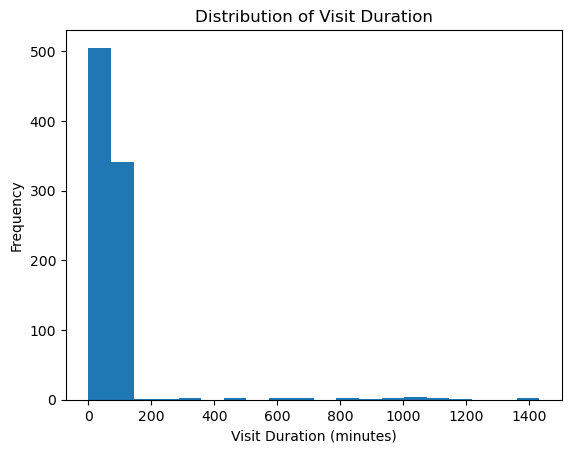

In [102]:
## plot a histogram of the visit_duration_minutes column
import matplotlib.pyplot as plt
plt.hist(df['visit_duration_minutes'], bins=20)
plt.xlabel('Visit Duration (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Visit Duration')
plt.show()


In [103]:
# inspect outliers in the visit_duration_minutes column
df[df['visit_duration_minutes'] > 120]['urgent_case'].value_counts()

urgent_case
False    26
True      7
Name: count, dtype: Int64

In [104]:
# keep urgent_case that are greater than 120 minutes but drop the non-urgent cases that are greater than 120 minutes
df = df[~((df['visit_duration_minutes'] > 120) & (df['urgent_case'] == False))]

In [105]:
# given answer from the responded, assume that the travel duration is 15 minutes at the beginning of the day and the rest will calculate the travel distance minute from the last visit date 

# sort value by nurse_id and visit_start_time

df = df.sort_values(["nurse_id", "visit_start_time"])

df["prev_visit_end_time"] = df.groupby("nurse_id")["visit_end_time"].shift(1)

same_day = (
    df["visit_start_time"].dt.date ==
    df["prev_visit_end_time"].dt.date
)

df["travel_duration_min"] = (
    (df["visit_start_time"] - df["prev_visit_end_time"])
    .dt.total_seconds() / 60
)

df.loc[~same_day, "travel_duration_min"] = None

df.head()



,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes,urgent_case,revisit_case,visit_duration_minutes,prev_visit_end_time,travel_duration_min
85,a7c0d48c-26d5-47f4-a5c6-97b93fb08c0b,P60703,N1066,2025-08-20 20:30:41,2025-08-20 21:42:41,Medicatn Adminstratino,East,<NA>,False,False,72.0,NaT,NaN
827,ec09fa84-50de-4670-91f1-83a2b290f1cb,P89830,N1066,2025-08-26 06:00:49,2025-08-26 06:01:49,Medication Administration,North,Follow-up is required. The nurse delivered the...,False,True,1.0,2025-08-20 21:42:41,NaN
71,b64afacd-cb51-40c3-bb57-e054ae3ea082,P76027,N1066,2025-09-06 17:45:30,2025-09-06 18:31:30,Physical Therapy,South,Monitoring is required. The nurse encouraged t...,False,False,46.0,2025-08-26 06:01:49,NaN
578,4d217cf0-d5bf-4c54-9072-9ac0ada81d1f,P35198,N1066,2025-09-06 20:23:00,2025-09-06 21:02:00,General Check-up,East,The nurse checked the oxygen level. The patien...,False,False,39.0,2025-09-06 18:31:30,111.5
980,1055d02d-3484-430b-bfb2-b59fc9431683,P60246,N1066,2025-09-07 19:42:23,2025-09-07 20:53:23,Wound Care,South,The nurse changed the bandage. The patient is ...,True,False,71.0,2025-09-06 21:02:00,NaN


In [106]:
df[df['travel_duration_min'].isna()]

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes,urgent_case,revisit_case,visit_duration_minutes,prev_visit_end_time,travel_duration_min
85,a7c0d48c-26d5-47f4-a5c6-97b93fb08c0b,P60703,N1066,2025-08-20 20:30:41,2025-08-20 21:42:41,Medicatn Adminstratino,East,<NA>,False,False,72.000000,NaT,NaN
827,ec09fa84-50de-4670-91f1-83a2b290f1cb,P89830,N1066,2025-08-26 06:00:49,2025-08-26 06:01:49,Medication Administration,North,Follow-up is required. The nurse delivered the...,False,True,1.000000,2025-08-20 21:42:41,NaN
71,b64afacd-cb51-40c3-bb57-e054ae3ea082,P76027,N1066,2025-09-06 17:45:30,2025-09-06 18:31:30,Physical Therapy,South,Monitoring is required. The nurse encouraged t...,False,False,46.000000,2025-08-26 06:01:49,NaN
980,1055d02d-3484-430b-bfb2-b59fc9431683,P60246,N1066,2025-09-07 19:42:23,2025-09-07 20:53:23,Wound Care,South,The nurse changed the bandage. The patient is ...,True,False,71.000000,2025-09-06 21:02:00,NaN
642,b790571b-f509-43a8-834d-f6d5c1c9076b,P20842,N1066,2025-09-08 22:16:00,2025-09-09 00:10:19,General Check-up,North,The nurse checked the temperature. The patient...,False,False,114.316667,2025-09-07 20:53:23,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,9d913992-96c4-492d-980b-8e301e42ae59,P79915,N9993,2025-09-11 11:42:00,2025-09-11 13:29:00,Wound Care,North,The nurse dressed the bandage. The patient is ...,False,False,107.000000,2025-09-08 03:37:30,NaN
181,e60db5a4-f79a-43a7-a2f2-61fce0bfffa6,P46495,N9993,2025-09-13 07:12:35,2025-09-13 08:22:35,Medication Administration,East,The nurse provided the oral dose. The patient ...,False,False,70.000000,2025-09-11 13:29:00,NaN
616,eef49c6e-c3b1-4ba4-9b73-5db08c6316ce,P67511,N9993,2025-09-15 17:48:56,2025-09-15 18:53:00,Medication Administration,East,<NA>,False,False,64.066667,2025-09-13 08:22:35,NaN
161,02fcc9aa-4d2f-45b7-aa14-ffef29bfac34,P25961,N9993,2025-09-16 00:16:16,2025-09-16 00:24:24,Wound Care,South,The nurse changed the wound dressing. The pati...,False,False,8.133333,2025-09-15 18:53:00,NaN


In [107]:
# have multiple negative travel duration minutes which is not possible, so the nurse might have made a mistake in the visit_end_time column for those visits, so we will replace those negative travel duration minutes with 15 minutes
df[df['travel_duration_min'] < 0].sort_values(["visit_start_time"])

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes,urgent_case,revisit_case,visit_duration_minutes,prev_visit_end_time,travel_duration_min
306,50cfbc16-0e45-46a6-9b31-6141dc769426,P70463,N4803,2025-08-24 10:40:00,2025-08-24 12:40:36,General Chek-up,North,The nurse reviewed the vital signs. The patien...,True,False,120.600000,2025-08-24 11:03:42,-23.700000
422,f1cececd-6fdf-40c6-9d48-d9c938bd0fd3,P12126,N1841,2025-08-26 07:29:16,2025-08-26 09:29:00,General Check-up,North,Ongoing assessment is required. The nurse obse...,False,False,119.733333,2025-08-26 07:43:34,-14.300000
398,d9d76fdf-7d08-4c13-a956-fb12f4637ad2,P17752,N8955,2025-08-27 06:32:26,2025-08-27 07:50:26,Medication Administration,South,The nurse delivered the oral dose. The patient...,False,False,78.000000,2025-08-27 07:46:23,-73.950000
415,a565df77-ac13-41e7-a6f8-ac953f5bf42b,P42865,N9403,2025-08-31 11:44:00,2025-08-31 12:30:00,Medication Administration,West,<NA>,False,False,46.000000,2025-08-31 12:52:28,-68.466667
291,63fc0673-ae80-4808-8a82-92c920769d6b,P75810,N9880,2025-09-02 04:12:36,2025-09-02 04:55:00,Physical Therapy,East,The nurse assisted the gait practice. The pati...,False,False,42.400000,2025-09-02 04:36:00,-23.400000
404,41ba91f9-c219-422f-96ec-fb9e28361ef7,P29486,N7276,2025-09-02 17:55:00,2025-09-02 19:00:04,Physical Therapy,East,Review is required. The nurse monitored the st...,False,False,65.066667,2025-09-02 18:57:38,-62.633333
747,904dad76-ea95-4471-8f5f-7861afebd9bf,P19151,N1568,2025-09-05 14:38:00,2025-09-05 15:35:00,Medication Administration,East,The nurse delivered the oral dose. The patient...,False,False,57.000000,2025-09-05 15:50:20,-72.333333
209,c0671144-1e77-44e7-a5b8-48d2b1458dd4,P77745,N3012,2025-09-11 10:22:33,2025-09-11 12:05:33,Wound Care,East,Ongoing assessment is required. The nurse chan...,False,False,103.000000,2025-09-11 10:31:15,-8.700000
357,e839f4f7-d38e-4cb0-9d26-dbcd1c01863a,P91422,N8286,2025-09-11 19:54:33,2025-09-11 21:34:33,General Check-up,Easst,The nurse observed the vital signs. The patien...,False,False,100.000000,2025-09-11 20:00:00,-5.450000
163,164b1d50-78b8-432c-8adb-19f0fc700d2a,P93308,N2273,2025-09-13 14:29:00,2025-09-13 15:59:00,Medicatn Adminstratino,North,The nurse encouraged the strength training. Th...,False,False,90.000000,2025-09-13 15:44:51,-75.850000


In [108]:
## inspect the visit for nurse N4803 to see if there are any negative travel duration minutes

df[df["nurse_id"] == "N4803"].sort_values("visit_start_time")[
    ["visit_start_time","visit_end_time","prev_visit_end_time","travel_duration_min","service_type","patient_id"]
]

,visit_start_time,visit_end_time,prev_visit_end_time,travel_duration_min,service_type,patient_id
989,2025-08-20 21:51:44,2025-08-20 22:52:44,NaT,NaN,General Check-up,P31135
194,2025-08-21 11:55:18,2025-08-21 12:40:18,2025-08-20 22:52:44,NaN,Physical Therapy,P80833
463,2025-08-24 09:18:42,2025-08-24 11:03:42,2025-08-21 12:40:18,NaN,General Check-up,P92720
306,2025-08-24 10:40:00,2025-08-24 12:40:36,2025-08-24 11:03:42,-23.700000,General Chek-up,P70463
145,2025-08-24 21:51:45,2025-08-24 22:47:00,2025-08-24 12:40:36,551.150000,Medication Administration,P90583
739,2025-08-27 03:56:40,2025-08-27 05:17:40,2025-08-24 22:47:00,NaN,Wound Care,P38281
79,2025-08-27 22:26:00,2025-08-28 00:24:00,2025-08-27 05:17:40,1028.333333,Wound Care,P68200
571,2025-08-28 12:58:03,2025-08-28 13:55:03,2025-08-28 00:24:00,754.050000,Medication Administration,P69178
769,2025-09-04 12:26:44,2025-09-04 12:33:00,2025-08-28 13:55:03,NaN,Wound Cae,P51093
183,2025-09-06 07:50:00,2025-09-06 08:37:01,2025-09-04 12:33:00,NaN,Physical Therapy,P32952


In [109]:
## reconfirm the hypothesis that there are some negative travel duration minutes for nurse N9880 so it could be a platform error or multiple tratment in one visit 

df[df["nurse_id"] == "N9880"].sort_values("visit_start_time")[
    ["visit_start_time","visit_end_time","prev_visit_end_time","travel_duration_min","service_type","patient_id"]
]

,visit_start_time,visit_end_time,prev_visit_end_time,travel_duration_min,service_type,patient_id
428,2025-08-23 20:53:25,2025-08-23 20:54:00,NaT,NaN,Medication Administration,P94267
169,2025-08-25 01:25:20,NaT,2025-08-23 20:54:00,NaN,Wound Care,P66550
454,2025-08-26 07:18:11,2025-08-26 07:19:00,NaT,NaN,General Check-up,P79086
157,2025-09-02 04:08:00,2025-09-02 04:36:00,2025-08-26 07:19:00,NaN,Wound Care,P13508
291,2025-09-02 04:12:36,2025-09-02 04:55:00,2025-09-02 04:36:00,-23.4,Physical Therapy,P75810
987,2025-09-10 15:30:14,2025-09-10 17:20:14,2025-09-02 04:55:00,NaN,General Check-up,P52296
751,2025-09-17 00:18:18,2025-09-17 02:11:18,2025-09-10 17:20:14,NaN,Wound Care,P42892


In [110]:
## For data imputation, we will replace NaN values in the travel_duration_min column with 15 minutes as the default travel duration for the first visit of the day for each nurse 
## For the negative travel duration minutes which is not possible, we will replace with 999 and will not impute those values with 15 minutes because it is not possible to have negative travel duration minutes and it could be a platform error or multiple tratment in one visit, so we will keep those negative values as it is for now and will investigate further in the future analysis.

df_test = df.copy()
df_test['travel_duration_min'] = df_test['travel_duration_min'].fillna(15)
df_test.loc[df_test['travel_duration_min'] < 0, 'travel_duration_min'] = 999


In [111]:
df_test[df_test['travel_duration_min'] == 999]

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes,urgent_case,revisit_case,visit_duration_minutes,prev_visit_end_time,travel_duration_min
747,904dad76-ea95-4471-8f5f-7861afebd9bf,P19151,N1568,2025-09-05 14:38:00,2025-09-05 15:35:00,Medication Administration,East,The nurse delivered the oral dose. The patient...,False,False,57.000000,2025-09-05 15:50:20,999.0
422,f1cececd-6fdf-40c6-9d48-d9c938bd0fd3,P12126,N1841,2025-08-26 07:29:16,2025-08-26 09:29:00,General Check-up,North,Ongoing assessment is required. The nurse obse...,False,False,119.733333,2025-08-26 07:43:34,999.0
163,164b1d50-78b8-432c-8adb-19f0fc700d2a,P93308,N2273,2025-09-13 14:29:00,2025-09-13 15:59:00,Medicatn Adminstratino,North,The nurse encouraged the strength training. Th...,False,False,90.000000,2025-09-13 15:44:51,999.0
209,c0671144-1e77-44e7-a5b8-48d2b1458dd4,P77745,N3012,2025-09-11 10:22:33,2025-09-11 12:05:33,Wound Care,East,Ongoing assessment is required. The nurse chan...,False,False,103.000000,2025-09-11 10:31:15,999.0
539,ccbfbce2-0498-47ce-a9de-3ce903a33e18,P59581,N4701,2025-09-15 22:26:00,2025-09-15 23:24:56,Medication Administration,South,ASAP is required. The nurse administered the I...,True,False,58.933333,2025-09-15 23:27:00,999.0
306,50cfbc16-0e45-46a6-9b31-6141dc769426,P70463,N4803,2025-08-24 10:40:00,2025-08-24 12:40:36,General Chek-up,North,The nurse reviewed the vital signs. The patien...,True,False,120.600000,2025-08-24 11:03:42,999.0
404,41ba91f9-c219-422f-96ec-fb9e28361ef7,P29486,N7276,2025-09-02 17:55:00,2025-09-02 19:00:04,Physical Therapy,East,Review is required. The nurse monitored the st...,False,False,65.066667,2025-09-02 18:57:38,999.0
357,e839f4f7-d38e-4cb0-9d26-dbcd1c01863a,P91422,N8286,2025-09-11 19:54:33,2025-09-11 21:34:33,General Check-up,Easst,The nurse observed the vital signs. The patien...,False,False,100.000000,2025-09-11 20:00:00,999.0
679,cf37d6bb-814f-41f1-b23f-ec032367991c,P86552,N8286,2025-09-16 19:55:00,2025-09-16 21:08:09,General Check-up,North,<NA>,False,False,73.150000,2025-09-16 20:31:00,999.0
398,d9d76fdf-7d08-4c13-a956-fb12f4637ad2,P17752,N8955,2025-08-27 06:32:26,2025-08-27 07:50:26,Medication Administration,South,The nurse delivered the oral dose. The patient...,False,False,78.000000,2025-08-27 07:46:23,999.0


In [112]:
df_test[df_test['travel_duration_min'] > 0]

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes,urgent_case,revisit_case,visit_duration_minutes,prev_visit_end_time,travel_duration_min
85,a7c0d48c-26d5-47f4-a5c6-97b93fb08c0b,P60703,N1066,2025-08-20 20:30:41,2025-08-20 21:42:41,Medicatn Adminstratino,East,<NA>,False,False,72.000000,NaT,15.0
827,ec09fa84-50de-4670-91f1-83a2b290f1cb,P89830,N1066,2025-08-26 06:00:49,2025-08-26 06:01:49,Medication Administration,North,Follow-up is required. The nurse delivered the...,False,True,1.000000,2025-08-20 21:42:41,15.0
71,b64afacd-cb51-40c3-bb57-e054ae3ea082,P76027,N1066,2025-09-06 17:45:30,2025-09-06 18:31:30,Physical Therapy,South,Monitoring is required. The nurse encouraged t...,False,False,46.000000,2025-08-26 06:01:49,15.0
578,4d217cf0-d5bf-4c54-9072-9ac0ada81d1f,P35198,N1066,2025-09-06 20:23:00,2025-09-06 21:02:00,General Check-up,East,The nurse checked the oxygen level. The patien...,False,False,39.000000,2025-09-06 18:31:30,111.5
980,1055d02d-3484-430b-bfb2-b59fc9431683,P60246,N1066,2025-09-07 19:42:23,2025-09-07 20:53:23,Wound Care,South,The nurse changed the bandage. The patient is ...,True,False,71.000000,2025-09-06 21:02:00,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,9d913992-96c4-492d-980b-8e301e42ae59,P79915,N9993,2025-09-11 11:42:00,2025-09-11 13:29:00,Wound Care,North,The nurse dressed the bandage. The patient is ...,False,False,107.000000,2025-09-08 03:37:30,15.0
181,e60db5a4-f79a-43a7-a2f2-61fce0bfffa6,P46495,N9993,2025-09-13 07:12:35,2025-09-13 08:22:35,Medication Administration,East,The nurse provided the oral dose. The patient ...,False,False,70.000000,2025-09-11 13:29:00,15.0
616,eef49c6e-c3b1-4ba4-9b73-5db08c6316ce,P67511,N9993,2025-09-15 17:48:56,2025-09-15 18:53:00,Medication Administration,East,<NA>,False,False,64.066667,2025-09-13 08:22:35,15.0
161,02fcc9aa-4d2f-45b7-aa14-ffef29bfac34,P25961,N9993,2025-09-16 00:16:16,2025-09-16 00:24:24,Wound Care,South,The nurse changed the wound dressing. The pati...,False,False,8.133333,2025-09-15 18:53:00,15.0


In [114]:
df_test[df_test['travel_duration_min'] < 999].describe()

,visit_start_time,visit_end_time,visit_duration_minutes,prev_visit_end_time,travel_duration_min
count,925,829,829.000000,734,925.000000
mean,2025-09-03 07:42:27.060540672,2025-09-03 12:05:18.854041088,64.421934,2025-09-02 01:39:01.318801152,54.195369
min,2025-08-19 12:19:00,2025-08-19 13:46:52,0.383333,2025-08-19 13:46:52,12.116667
25%,2025-08-27 03:47:46,2025-08-27 05:34:00,34.000000,2025-08-26 10:58:43.500000,15.000000
50%,2025-09-03 02:08:18,2025-09-03 12:04:30,61.000000,2025-09-02 00:44:42,15.000000
75%,2025-09-10 07:08:39,2025-09-10 18:26:05,91.983333,2025-09-08 05:06:40.750000128,15.000000
max,2025-09-18 11:34:02,2025-09-18 11:58:02,1025.983333,2025-09-17 19:15:00,954.983333
std,NaN,NaN,51.648078,NaN,139.820630


In [115]:
df_test[(df_test['travel_duration_min'] > 950) & (df_test['travel_duration_min'] < 999)]

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes,urgent_case,revisit_case,visit_duration_minutes,prev_visit_end_time,travel_duration_min
901,09425b83-b441-4ec8-bad2-f3d872266058,P96204,N9428,2025-09-14 17:30:16,2025-09-14 17:59:00,Medication Administration,East,The nurse administered the IV line. The patien...,True,False,28.733333,2025-09-14 01:35:17,954.983333


In [ ]:
## inspect the visit for nurse N9428 on 2025-09-14 and 2025-09-13 to see the outliers in the travel duration minutes which is greater than 950 minutes and less than 999 minutes
## impute the travel duration minutes for those outliers more than 120 minutes to 15 minutes because it is not possible to have travel duration minutes more than 120 minutes as it is proven on this dataset that the error come from the visit_end_time after mid night so it is a format error in the visit_end_time column for those visits, 
## so we will replace those outliers with 15 minutes as the default travel duration for the first visit of the day for each nurse 
df_test[(df_test['nurse_id'] == "N9428") & ((df_test['visit_start_time'].dt.date == pd.to_datetime("2025-09-14").date()) | (df_test['visit_start_time'].dt.date == pd.to_datetime("2025-09-13").date()))]

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes,urgent_case,revisit_case,visit_duration_minutes,prev_visit_end_time,travel_duration_min
448,6506fee8-ce89-4ee0-a601-e90dacc0e64b,P91422,N9428,2025-09-13 04:44:00,NaT,Wound Cae,North,The nurse monitored the blood pressure. The pa...,False,False,NaN,2025-09-12 04:28:41,15.000000
226,081eb18b-b96d-48a7-abe9-eebaebff1874,P62477,N9428,2025-09-13 23:35:17,2025-09-14 01:35:17,Wound Care,West,The nurse applied the bandage. The patient is ...,False,False,120.000000,NaT,15.000000
901,09425b83-b441-4ec8-bad2-f3d872266058,P96204,N9428,2025-09-14 17:30:16,2025-09-14 17:59:00,Medication Administration,East,The nurse administered the IV line. The patien...,True,False,28.733333,2025-09-14 01:35:17,954.983333


In [118]:
df_test.loc[(df_test['travel_duration_min'] > 120) & (df_test['travel_duration_min'] < 999), 'travel_duration_min'] = 15    

In [119]:
df_test[df_test['travel_duration_min'] < 999].describe()

,visit_start_time,visit_end_time,visit_duration_minutes,prev_visit_end_time,travel_duration_min
count,925,829,829.000000,734,925.000000
mean,2025-09-03 07:42:27.060540672,2025-09-03 12:05:18.854041088,64.421934,2025-09-02 01:39:01.318801152,15.766468
min,2025-08-19 12:19:00,2025-08-19 13:46:52,0.383333,2025-08-19 13:46:52,12.116667
25%,2025-08-27 03:47:46,2025-08-27 05:34:00,34.000000,2025-08-26 10:58:43.500000,15.000000
50%,2025-09-03 02:08:18,2025-09-03 12:04:30,61.000000,2025-09-02 00:44:42,15.000000
75%,2025-09-10 07:08:39,2025-09-10 18:26:05,91.983333,2025-09-08 05:06:40.750000128,15.000000
max,2025-09-18 11:34:02,2025-09-18 11:58:02,1025.983333,2025-09-17 19:15:00,111.500000
std,NaN,NaN,51.648078,NaN,7.264438
